In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv(r'C:\Users\ChristineKakina\PycharmProjects\HitSongPredictor\Kenya.csv')
df = data.copy()

# Quick look at the data
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            53 non-null     object 
 1   album             53 non-null     object 
 2   track_name        53 non-null     object 
 3   track_id          53 non-null     object 
 4   danceability      53 non-null     float64
 5   energy            53 non-null     float64
 6   key               53 non-null     int64  
 7   loudness          53 non-null     float64
 8   mode              53 non-null     int64  
 9   speechiness       53 non-null     float64
 10  instrumentalness  53 non-null     float64
 11  liveness          53 non-null     float64
 12  valence           53 non-null     float64
 13  tempo             53 non-null     float64
 14  duration_ms       53 non-null     int64  
 15  time_signature    53 non-null     int64  
dtypes: float64(8), int64(4), object(4)
memory usag

,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.700981,0.684472,5.584906,-6.981038,0.641509,0.184936,0.002764,0.146174,0.615925,123.243868,231153.867925,3.981132
std,0.131371,0.119826,3.477587,2.078627,0.484146,0.127412,0.014791,0.117756,0.162706,34.149882,70110.430041,0.366405
min,0.351000,0.442000,0.000000,-11.587000,0.000000,0.032800,0.000000,0.029100,0.279000,77.448000,139227.000000,3.000000
25%,0.628000,0.585000,2.000000,-8.199000,0.000000,0.081400,0.000000,0.094000,0.527000,96.980000,193358.000000,4.000000
50%,0.706000,0.687000,6.000000,-6.740000,1.000000,0.171000,0.000000,0.112000,0.615000,101.997000,223403.000000,4.000000
75%,0.792000,0.773000,9.000000,-5.562000,1.000000,0.254000,0.000104,0.155000,0.750000,149.979000,247980.000000,4.000000
max,0.928000,0.965000,11.000000,-3.313000,1.000000,0.510000,0.107000,0.657000,0.929000,187.936000,598074.000000,5.000000


In [80]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Drop irrelevant columns
drop_cols = ['duration_ms', 'tempo', 'key', 'time_signature','loudness','mode']
relevant_features = [col for col in numeric_cols if col not in drop_cols]

# Compute mean for each relevant feature
feature_means = df[relevant_features].mean().sort_values(ascending=False)
print("Mean values of relevant features:\n", feature_means)


Mean values of relevant features:
 danceability        0.700981
energy              0.684472
valence             0.615925
speechiness         0.184936
liveness            0.146174
instrumentalness    0.002764
dtype: float64


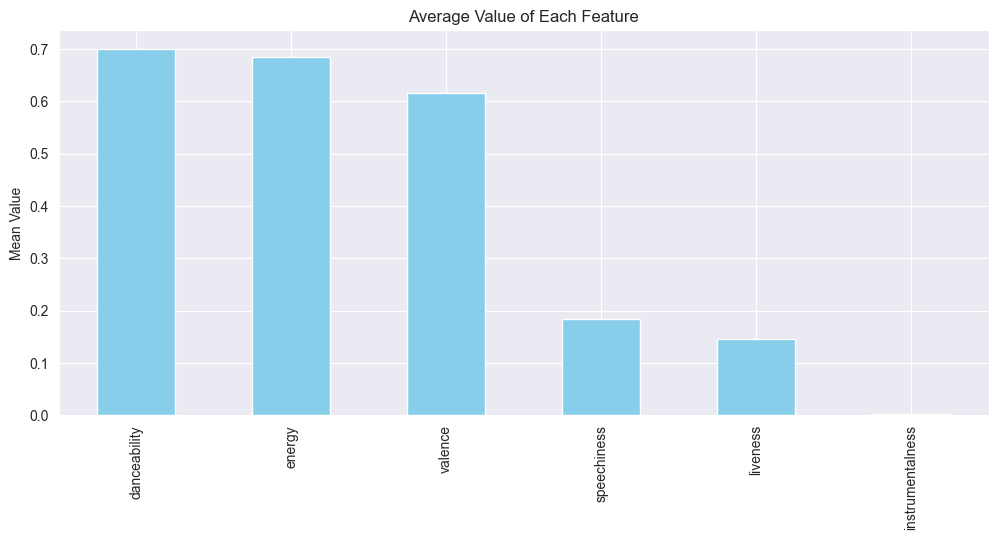

In [81]:
import matplotlib.pyplot as plt

# Bar plot of mean values
feature_means.plot(kind='bar', figsize=(12,5), color='skyblue')
plt.title('Average Value of Each Feature')
plt.ylabel('Mean Value')
plt.show()


In [82]:
# Suppose you pick the top 4 features based on the mean
top_features = feature_means.head(5).index.tolist()
print("Top features to use:", top_features)


Top features to use: ['danceability', 'energy', 'valence', 'speechiness', 'liveness']


In [83]:
# Select top features
features = ['liveness', 'speechiness', 'danceability', 'energy','valence']

# Create a 'hit_score' as average of normalized top features
df['hit_score'] = df[features].mean(axis=1)

# Define a threshold (e.g., median or top 30%) to classify hits
threshold = df['hit_score'].median()
df['hit_status'] = (df['hit_score'] >= threshold).astype(int)  # 1 = banger, 0 = flop

df[['track_name', 'hit_score', 'hit_status']].head()
df[['track_name', 'hit_score', 'hit_status']]

,track_name,hit_score,hit_status
0,Hello,0.43546,0
1,Properly (feat. Femi One),0.51370,1
2,Hapo Tu (feat. Chris Kaiga),0.47182,1
3,Mungu Pekee,0.49628,1
4,Bebi Bebi,0.42992,0
5,Short N Sweet,0.48700,1
6,Suzanna,0.49618,1
7,Midnight Train,0.46920,0
8,Insecure,0.40520,0
9,Sura Yako,0.52360,1


# USING LINEAR ALGEBRA TO CREATE A FORMULA TO PREDICT A SONG


In [84]:
import numpy as np

# Features matrix for all songs
X = df[features].values  # shape (num_songs, 5)
print(X)
print(df)
# Target vector
y = df['hit_score'].values  # shape (num_songs,)

# Solve for coefficients using least squares
coefficients, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

# Display coefficients
coeff_dict = dict(zip(features, coefficients))
print("Multiplication coefficients for all songs:")
for feat, coef in coeff_dict.items():
    print(f"{feat}: {coef:.4f}")



[[0.0783 0.166  0.633  0.695  0.605 ]
 [0.0295 0.366  0.909  0.56   0.704 ]
 [0.0291 0.343  0.726  0.706  0.555 ]
 [0.0624 0.173  0.718  0.759  0.769 ]
 [0.0456 0.166  0.708  0.442  0.788 ]
 [0.163  0.23   0.671  0.687  0.684 ]
 [0.103  0.0519 0.793  0.778  0.755 ]
 [0.164  0.184  0.698  0.773  0.527 ]
 [0.122  0.104  0.68   0.585  0.535 ]
 [0.139  0.171  0.561  0.965  0.782 ]
 [0.125  0.0597 0.73   0.673  0.632 ]
 [0.249  0.0328 0.705  0.588  0.86  ]
 [0.406  0.349  0.592  0.795  0.615 ]
 [0.102  0.0442 0.351  0.479  0.355 ]
 [0.0553 0.134  0.426  0.541  0.593 ]
 [0.165  0.254  0.591  0.53   0.6   ]
 [0.13   0.261  0.736  0.482  0.644 ]
 [0.327  0.333  0.741  0.692  0.664 ]
 [0.0534 0.0418 0.751  0.811  0.83  ]
 [0.0988 0.133  0.58   0.56   0.415 ]
 [0.154  0.259  0.757  0.559  0.556 ]
 [0.0987 0.0822 0.836  0.641  0.56  ]
 [0.0998 0.0816 0.783  0.773  0.929 ]
 [0.107  0.0443 0.8    0.731  0.443 ]
 [0.118  0.0686 0.847  0.616  0.692 ]
 [0.0994 0.375  0.628  0.753  0.615 ]
 [0.0778 0.2

# MODELLING

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [87]:
# Features and target
features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']
X = df[features]
y = df['hit_score']

# Split data 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


# FIRST MODEL:Linear Regression

In [88]:
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Linear Regression:")
print("Coefficients:", dict(zip(features, lr_model.coef_)))
print("Intercept:", lr_model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


Linear Regression:
Coefficients: {'liveness': np.float64(0.19999999999999982), 'speechiness': np.float64(0.2), 'danceability': np.float64(0.20000000000000018), 'energy': np.float64(0.19999999999999998), 'valence': np.float64(0.19999999999999987)}
Intercept: 1.1102230246251565e-16
R2 Score: 1.0
MSE: 1.266833918974715e-32


# SECOND MODEL:Random Forest

In [89]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest:
R2 Score: 0.6332268821237077
MSE: 0.002005393078392596


# Third Model: Gradient Boosting

In [90]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\nGradient Boosting:")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))


Gradient Boosting:
R2 Score: 0.7144495070946391
MSE: 0.0015612948553038425


In [91]:
comparison = pd.DataFrame({
    'track_name': df.loc[y_test.index, 'track_name'],
    'actual_hit_score': y_test,
    'pred_lr': y_pred_lr,
    'pred_rf': y_pred_rf,
    'pred_gb': y_pred_gb
})

print(comparison.sort_values('actual_hit_score', ascending=False).head(10))


              track_name  actual_hit_score  pred_lr   pred_rf   pred_gb
47  Kamati Ya Roho Chafu           0.62800  0.62800  0.516200  0.532129
49           Accelerator           0.55940  0.55940  0.535119  0.556569
17                  Hepi           0.55140  0.55140  0.472202  0.478895
12          Thick Thighs           0.55140  0.55140  0.475641  0.486741
43               Tarimbo           0.55020  0.55020  0.537514  0.545213
36       Such Kinda Love           0.52830  0.52830  0.504213  0.493637
30                Rewind           0.52440  0.52440  0.504241  0.495907
9              Sura Yako           0.52360  0.52360  0.515224  0.518592
50               KISHASH           0.51000  0.51000  0.459717  0.473080
3            Mungu Pekee           0.49628  0.49628  0.505456  0.498967


# Top 10 using linear regression

In [92]:
# Add predicted hit scores for test set
df.loc[y_test.index, 'predicted_hit_score_lr'] = y_pred_lr

#Sort and display
top_10_lr = df.loc[y_test.index, ['track_name', 'hit_score', 'predicted_hit_score_lr']]\
    .sort_values('predicted_hit_score_lr', ascending=False).head(10)

print(top_10_lr)


              track_name  hit_score  predicted_hit_score_lr
47  Kamati Ya Roho Chafu    0.62800                 0.62800
49           Accelerator    0.55940                 0.55940
17                  Hepi    0.55140                 0.55140
12          Thick Thighs    0.55140                 0.55140
43               Tarimbo    0.55020                 0.55020
36       Such Kinda Love    0.52830                 0.52830
30                Rewind    0.52440                 0.52440
9              Sura Yako    0.52360                 0.52360
50               KISHASH    0.51000                 0.51000
3            Mungu Pekee    0.49628                 0.49628


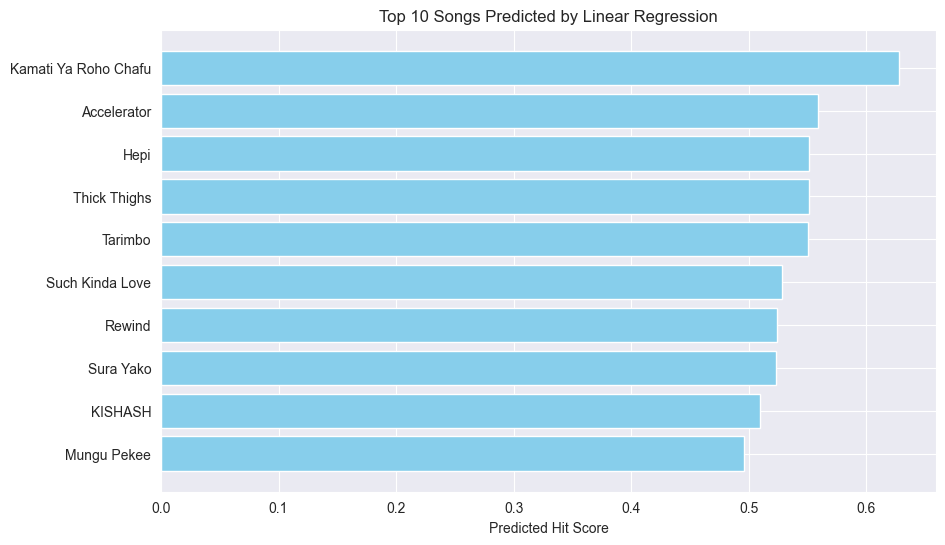

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_10_lr['track_name'], top_10_lr['predicted_hit_score_lr'], color='skyblue')
plt.xlabel('Predicted Hit Score')
plt.title('Top 10 Songs Predicted by Linear Regression')
plt.gca().invert_yaxis()  # highest on top
plt.show()


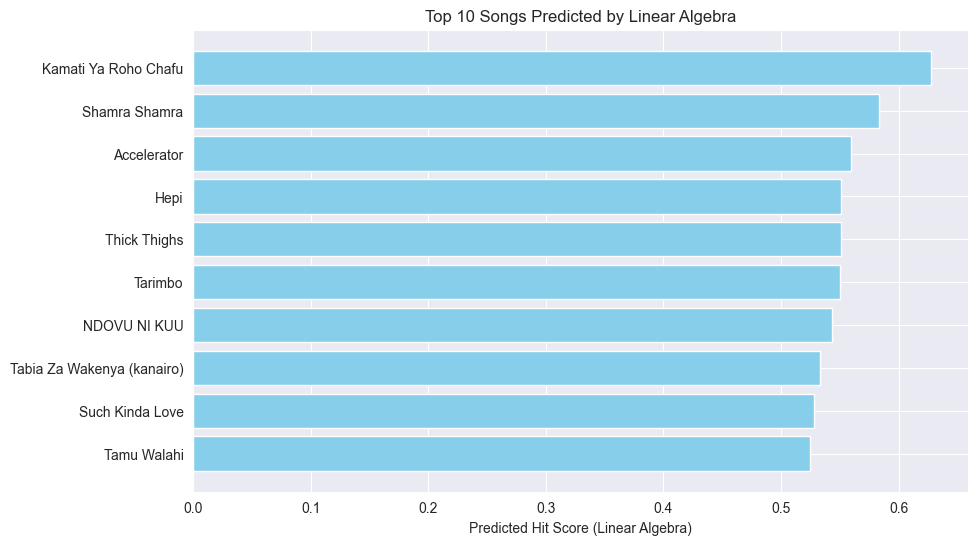

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_10_la['track_name'], top_10_la['predicted_hit_score'], color='skyblue')
plt.xlabel('Predicted Hit Score (Linear Algebra)')
plt.title('Top 10 Songs Predicted by Linear Algebra')
plt.gca().invert_yaxis()  # highest on top
plt.show()

# Merge top 10 Linear Algebra and Linear Equation


In [100]:
# Merge on track_name to see differences
comparison_top10 = pd.merge(
    top_10_lr[['track_name', 'predicted_hit_score_lr']],
    top_10_la[['track_name', 'predicted_hit_score']],
    on='track_name',
    how='outer'
)

# Fill missing values with 0 (if some songs are only in one list)
comparison_top10 = comparison_top10.fillna(0)

# Add difference column
comparison_top10['score_diff'] = comparison_top10['predicted_hit_score_lr'] - comparison_top10['predicted_hit_score']

# Sort by Linear Regression predicted score
comparison_top10 = comparison_top10.sort_values('predicted_hit_score_lr', ascending=False)

print(comparison_top10)


                    track_name  predicted_hit_score_lr  predicted_hit_score  \
3         Kamati Ya Roho Chafu                 0.62800              0.62800   
0                  Accelerator                 0.55940              0.55940   
1                         Hepi                 0.55140              0.55140   
13                Thick Thighs                 0.55140              0.55140   
12                     Tarimbo                 0.55020              0.55020   
8              Such Kinda Love                 0.52830              0.52830   
6                       Rewind                 0.52440              0.00000   
9                    Sura Yako                 0.52360              0.00000   
2                      KISHASH                 0.51000              0.00000   
4                  Mungu Pekee                 0.49628              0.00000   
5                 NDOVU NI KUU                 0.00000              0.54340   
7                Shamra Shamra                 0.000

In [103]:
# Coefficients from Linear Regression
lr_importance = pd.Series(lr_model.coef_, index=features).sort_values(ascending=False)
print("Linear Regression Feature Importance:\n", lr_importance)




Linear Regression Feature Importance:
 danceability    0.2
speechiness     0.2
energy          0.2
valence         0.2
liveness        0.2
dtype: float64
